# Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import spectral_norm
from torchvision.utils import save_image
from torch_fidelity import calculate_metrics

from sklearn.model_selection import train_test_split 
import numpy as np

import matplotlib.pyplot as plt

import datetime 
from tqdm import tqdm
import os, shutil


In [2]:
DEVICE  = torch.device(f"cuda:0" if torch.cuda.is_available() else "cpu")
#DEVICE  = "cpu"
print(DEVICE)


cpu


In [3]:
base_path = "../Dataset"

dataset = base_path + "/s2-utm-33N-18E-242N-2018"
train_geojson_path = base_path + "/br-18E-242N-crop-labels-train-2018.geojson"

folder = "/DS3"
subfolder1 = "/Temporal Data"

data_path = dataset+folder
temporal_data_path = dataset+folder+subfolder1


# Load Data

In [ ]:
# data_original = np.load((temporal_data_path+'/9_selected_time_range_filtered_data_27_day_majority60.npy'))
# data_augmented = np.load((temporal_data_path+'/12_selected_time_range_augumented_data_27_day.npy'))

# final_gan_data = np.empty((0, 27, 64, 64, 4))
# final_gan_labels = np.empty((0, 64, 64))

# majority_original_labels = np.load(temporal_data_path+'/10_selected_time_range_filtered_labels_27_day_majority60.npy')
# agumenmted_labels = np.load(temporal_data_path+'/8_agumented_labels.npy')

# final_gan_labels = np.concatenate((final_gan_labels, majority_original_labels), axis=0)
# final_gan_labels = np.concatenate((final_gan_labels, agumenmted_labels), axis=0)
# final_gan_labels = final_gan_labels.astype(np.int16)

# final_gan_data = np.concatenate((final_gan_data, data_original), axis=0)
# final_gan_data = np.concatenate((final_gan_data, data_augmented), axis=0)
# final_gan_data = final_gan_data.astype(np.float16)

# print(type(final_gan_data[0,0,0,0,0]))
# print(type(final_gan_labels[0,0,0]))

# np.save((temporal_data_path+'/14_final_TGAN_data.npy'), final_gan_data)
# np.save((temporal_data_path+'/15_final_TGAN_labels.npy'), final_gan_labels)


<class 'numpy.float16'>
<class 'numpy.int16'>


In [4]:
final_gan_data = np.load((temporal_data_path+'/14_final_TGAN_data.npy'))
final_gan_labels = np.load((temporal_data_path+'/15_final_TGAN_labels.npy'))
doy_list = np.load((temporal_data_path+'/13_selected_dates_DOY_normalised.npy'))

labels_upadated = np.where(final_gan_labels == -1, 0, final_gan_labels)
train_data, validation_data, train_labels, validation_labels = train_test_split(final_gan_data, labels_upadated, test_size=0.4, random_state= 2) 

# np.save((temporal_data_path+'/20_final_TGAN_train_data.npy'), train_data)
# np.save((temporal_data_path+'/21_final_TGAN_train_labels.npy'), train_labels)
# np.save((temporal_data_path+'/22_final_TGAN_validation_data.npy'), validation_data)
# np.save((temporal_data_path+'/23_final_TGAN_validation_labels.npy'), validation_labels)


In [5]:
print(final_gan_data.shape)
print(final_gan_labels.shape)
print(train_data.shape)
print(train_labels.shape)


(4403, 27, 64, 64, 4)
(4403, 64, 64)
(2641, 27, 64, 64, 4)
(2641, 64, 64)


# TGAN model

## Generator

In [6]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, heads=4, dim_ff=512, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim_ff),
            nn.GELU(),
            nn.Linear(dim_ff, dim),
        )

    def forward(self, x):
        x_res = x
        x = self.norm1(x)
        x, _ = self.attn(x, x, x)
        x = x + x_res

        x_res = x
        x = self.norm2(x)
        x = self.ff(x) + x_res
        return x
    
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            spectral_norm(nn.Conv2d(channels, channels, 3, padding=1)),
            nn.ReLU(),
            spectral_norm(nn.Conv2d(channels, channels, 3, padding=1)),
        )

    def forward(self, x):
        return x + self.block(x)
    
class UNetTransformerGenerator(nn.Module):
    def __init__(self, in_channels=14, out_channels=4, emb_dim=512, num_heads=8, depth=4):
        super().__init__()

        # Encoder
        self.enc1 = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels, 64, 3, padding=1)), 
            nn.ReLU(),
            spectral_norm(nn.Conv2d(64, 64, 3, padding=1)), 
            nn.ELU(),
            ResidualBlock(64)
        )
        self.enc2 = nn.Sequential(
            nn.MaxPool2d(2),
            spectral_norm(nn.Conv2d(64, 128, 3, padding=1)),
            nn.GELU(),
            ResidualBlock(128)
        )
        self.enc3 = nn.Sequential(
            nn.MaxPool2d(2),
            spectral_norm(nn.Conv2d(128, 256, 3, padding=1)),
            nn.ReLU(),
            ResidualBlock(256)
        )
        self.enc4 = nn.Sequential(
            nn.MaxPool2d(2),
            spectral_norm(nn.Conv2d(256, emb_dim, 3, padding=1)),  # 512 default
            nn.GELU(),
            ResidualBlock(emb_dim)
        )

        # Transformer
        self.flatten = nn.Flatten(2)
        self.transformers = nn.Sequential(*[
            TransformerBlock(emb_dim, heads=num_heads) for _ in range(depth)
        ])
        self.unflatten = lambda x: x.view(x.size(0), emb_dim, 8, 8)

        # Decoder
        self.dec4 = nn.Sequential(
            ResidualBlock(emb_dim),
            nn.Upsample(scale_factor=2),
            spectral_norm(nn.Conv2d(emb_dim, 256, 3, padding=1)),
            nn.ReLU()
        )
        self.dec3 = nn.Sequential(
            ResidualBlock(512),  # 256 from dec4 + 256 from enc3
            nn.Upsample(scale_factor=2),
            spectral_norm(nn.Conv2d(512, 128, 3, padding=1)),
            nn.ReLU()
        )
        self.dec2 = nn.Sequential(
            ResidualBlock(256),  # 128 + 128
            nn.Upsample(scale_factor=2),
            spectral_norm(nn.Conv2d(256, 64, 3, padding=1)),
            nn.ReLU()
        )
        self.dec1 = nn.Sequential(
            ResidualBlock(128),  # 64 + 64
            spectral_norm(nn.Conv2d(128, out_channels, 3, padding=1)),
            nn.Tanh()
        )

    def forward(self, noise, label_map):
        x = torch.cat([noise, label_map], dim=1)  # [B, 14, 64, 64]

        e1 = self.enc1(x)        # [B, 64, 64, 64]
        e2 = self.enc2(e1)       # [B, 128, 32, 32]
        e3 = self.enc3(e2)       # [B, 256, 16, 16]
        e4 = self.enc4(e3)       # [B, 512, 8, 8]

        x_flat = self.flatten(e4).permute(0, 2, 1)  # [B, 64, 512]
        x_trans = self.transformers(x_flat)
        x_unflat = self.unflatten(x_trans.permute(0, 2, 1))  # [B, 512, 8, 8]

        d4 = self.dec4(x_unflat)                         # [B, 256, 16, 16]
        d3 = self.dec3(torch.cat([d4, e3], dim=1))       # [B, 128, 32, 32]
        d2 = self.dec2(torch.cat([d3, e2], dim=1))       # [B, 64, 64, 64]
        d1 = self.dec1(torch.cat([d2, e1], dim=1))       # [B, out_channels, 64, 64]

        return d1


## Discriminator

In [7]:
class DiscriminatorWithLabelEmbedding(nn.Module):
    def __init__(self, in_channels=4, label_classes=10, base_channels=64):
        super().__init__()

        self.img_conv = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 4, 2, 1),  # [B, 64, 32, 32]
            nn.LeakyReLU(0.2)
        )

        self.label_embed = nn.Sequential(
            nn.Conv2d(label_classes, base_channels, 4, 2, 1),
            nn.LeakyReLU(0.2)
        )

        # Save layers individually to extract features
        self.conv1 = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 2, 4, 2, 1),
            nn.BatchNorm2d(base_channels * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 4, 4, 2, 1),
            nn.BatchNorm2d(base_channels * 4),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
        )
        self.final = nn.Conv2d(base_channels * 4, 1, 8)  # [B, 1, 1, 1]

    def forward(self, img, label_map):
        label_map = label_map.float()
        img_feat = self.img_conv(img.float())           # [B, 64, 32, 32]
        label_feat = self.label_embed(label_map)        # [B, 64, 32, 32]
        x = torch.cat([img_feat, label_feat], dim=1)    # [B, 128, 32, 32]

        feats = []

        x = self.conv1(x)        
        feats.append(x.mean([2, 3]))  # Global avg pooled features

        x = self.conv2(x)
        feats.append(x.mean([2, 3]))

        out = self.final(x)               # [B, 1, 1, 1]
        out = out.view(-1, 1)

        return out, feats


In [8]:
# ---------- Temporal Controller: produces per-time noise maps ----------
class TemporalNoiseGenerator(nn.Module):
    """
    G^t: given a global latent z0 and simple time embeddings (sin/cos),
    generate a sequence of noise maps [B, T, 4, 64, 64] to drive the spatial G.
    """
    def __init__(self, noise_dim=128, time_feat_dim=16, out_channels=4,
                 base_ch=256, init_spatial=8):
        super().__init__()
        self.noise_dim = noise_dim
        self.time_in = nn.Linear(2, time_feat_dim)  # 2 = sin/cos
        self.rnn = nn.GRU(input_size=noise_dim + time_feat_dim,
                           hidden_size=noise_dim,
                           num_layers=1, batch_first=True, bidirectional=False)

        # map per-time latent -> small spatial tensor then upsample to 64x64
        self.proj = nn.Linear(noise_dim, base_ch * init_spatial * init_spatial)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(base_ch, base_ch//2, 4, 2, 1),  # 8->16
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(base_ch//2, base_ch//4, 4, 2, 1),  # 16->32
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(base_ch//4, out_channels, 4, 2, 1),  # 32->64
            nn.Tanh()  # keep noise in [-1, 1]
        )
        self.init_spatial = init_spatial
        self.base_ch = base_ch

    @torch.no_grad()
    def _time_sin_cos(self, doy_list, device):
        # normalized time indices 0..T-1 -> sin/cos features
        t = torch.tensor(doy_list).float().to(device)
        phase = 2.0 * torch.pi * t 
        return torch.stack([torch.sin(phase), torch.cos(phase)], dim=-1)  # [T,2]

    def forward(self, B, T, doy_list, device):
        # global latent z0 per sample
        z0 = torch.randn(B, self.noise_dim, device=device)
        #print("latent vector created")

        # time embeddings
        time_sc = self._time_sin_cos(doy_list, device)               # [T,2]
        time_feat = self.time_in(time_sc).unsqueeze(0).repeat(B, 1, 1)  # [B,T,tf]
        #print("time embeddings ready")

        # repeat z0 across time and concatenate with time features
        z_seq = z0.unsqueeze(1).repeat(1, T, 1)               # [B,T,noise_dim]
        rnn_in = torch.cat([z_seq, time_feat], dim=-1)        # [B,T,noise_dim+tf]
        #print("combining latent vector and time sequence")

        # temporal evolution
        h_seq, _ = self.rnn(rnn_in)                           # [B,T,noise_dim]
        #print("completed rnn")

        # per-time decoding to noise maps
        x = self.proj(h_seq)                                  # [B,T,base*8*8]
        x = x.view(B*T, self.base_ch, self.init_spatial, self.init_spatial)
        #print("data prepared for noise maps")
        noise_maps = self.decoder(x)                          # [B*T,4,64,64]
        noise_maps = noise_maps.view(B, T, 4, 64, 64)
        return noise_maps


# ---------- Temporal Sequence Discriminator: operates on per-frame features ----------
class TemporalDiscriminator(nn.Module):
    """
    D^t: consumes a sequence of per-frame features [B, T, F] and outputs [B,1].
    Use features coming from D^s (your spatial discriminator).
    """
    def __init__(self, feat_dim=384, hidden=256, layers=1, bidir=True):
        super().__init__()
        self.rnn = nn.GRU(feat_dim, hidden, num_layers=layers,
                          batch_first=True, bidirectional=bidir)
        out_dim = hidden * (2 if bidir else 1)
        self.fc = nn.Linear(out_dim, 1)

    def forward(self, feat_seq):  # [B,T,F]
        h, _ = self.rnn(feat_seq)           # [B,T,H*dir]
        # use last time step (or mean pool over time)
        h_last = h[:, -1, :]                # [B,H*dir]
        logit = self.fc(h_last)             # [B,1]
        return logit


In [9]:
class SequentialGeneratorWrapper(nn.Module):
    """
    Wraps your existing UNetTransformerGenerator (G^s) and a new TemporalNoiseGenerator (G^t).
    Forward returns a full sequence of frames: [B,T,4,64,64].
    """
    def __init__(self, spatial_generator: nn.Module, temporal_noise: TemporalNoiseGenerator):
        super().__init__()
        self.Gs = spatial_generator
        self.Gt = temporal_noise
    
    def fetch_temporal_generator(self):
        return self.Gt
    
    def fetch_spatial_generator(self):
        return self.Gs    

    def forward(self, one_hot_label_map, T, doy_list):
        """
        one_hot_label_map: [B, C_label, H, W]  (static over time)
        returns: fake_seq [B, T, 4, 64, 64]
        """
        B = one_hot_label_map.size(0)
        device = one_hot_label_map.device
        noise_seq = self.Gt(B, T, doy_list,  device)                     # [B,T,4,64,64]
        #print("noise maps ready")

        # Render frames with G^s; vectorize by flattening BT
        BT, C, H, W = B*T, noise_seq.size(2), 64, 64
        noise_bt = noise_seq.view(BT, C, H, W)
        labels_bt = one_hot_label_map.unsqueeze(1).repeat(1, T, 1, 1, 1).view(BT, -1, H, W)
        #print(f"data prepared for spatial gen. {noise_bt.shape} {labels_bt.shape}")
        fake_bt = self.Gs(noise_bt, labels_bt)                # [BT,4,64,64]
        fake_seq = fake_bt.view(B, T, 4, H, W)
        #print("generated image is ready")
        return fake_seq


## Helper functions

In [10]:
def load_models(Gs, Gt, Ds, Dt, G_optimizer, Ds_optimizer, D_optimizer_t, path):
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=True)
    
    Gs.load_state_dict(checkpoint['generator_spatial_state_dict'])
    Gt.load_state_dict(checkpoint['generator_temporal_state_dict'])
    Ds.load_state_dict(checkpoint['discriminator_spatial_state_dict'])
    Dt.load_state_dict(checkpoint['discriminator_temporal_state_dict'])

    G_optimizer.load_state_dict(checkpoint['g_optimizer_spatial_state_dict'])

    Ds_optimizer.load_state_dict(checkpoint['d_optimizer_spatial_state_dict'])
    D_optimizer_t.load_state_dict(checkpoint['d_optimizer_temporal_state_dict'])
    
    epoch = checkpoint.get('epoch', 0)
    print(f"Models loaded from {path} (Epoch {epoch})")
    return epoch

def save_models(Gs, Gt, Ds, Dt, G_optimizer, Ds_optimizer, D_optimizer_t, epoch, path, modelid=0):
    epoch+=1

    filename = r'/acgan_checkpoint-Model '+str(modelid)+r'-Epoch '+str(epoch)+r'_'+ str(datetime.date.today()) +r'.pth'
    full_path = path + filename
    #print(full_path)

    torch.save({
        'epoch': epoch,
        'generator_spatial_state_dict': Gs.state_dict(),
        'generator_temporal_state_dict': Gt.state_dict(),
        'discriminator_spatial_state_dict': Ds.state_dict(),
        'discriminator_temporal_state_dict': Dt.state_dict(),
        'g_optimizer_spatial_state_dict': G_optimizer.state_dict(),
        'd_optimizer_spatial_state_dict': Ds_optimizer.state_dict(),
        'd_optimizer_temporal_state_dict': D_optimizer_t.state_dict(),
    }, full_path)
    
    print(f"Models saved to {full_path}")


## Training loop

In [11]:
def train_tgan_sequential(Gs, 
                          Ds, 
                          Gt, 
                          Dt, 
                          g_optimizer, 
                          d_optimizer, 
                          d_optimizer_t,
                          dataloader,
                          doy_list, 
                          epochs, 
                          num_classes=10,
                          modelid=1, 
                          gen_iter=1,
                          w_adv_spatial=1.0,
                          w_adv_temporal=0.5,
                          w_featmatch=0.1, 
                          w_recon=25.0, 
                          w_smooth=2.0,
                          freeze_spatial_epochs = 0
                          ):
    T = 27

    loss_bce = nn.BCEWithLogitsLoss()
    losses_g, losses_d = [], []

    # Wrapper to generate sequences
    G = SequentialGeneratorWrapper(Gs, Gt).to(DEVICE)

    for epoch in range(epochs): 
        if epoch == 0:
            print("Test Save")
            save_models(G.fetch_spatial_generator(), 
                        G.fetch_temporal_generator(),
                        Ds,          
                        Dt,            
                        g_optimizer,
                        d_optimizer,
                        d_optimizer_t,
                        epoch, 
                        modelid=modelid, 
                        path=r'../GAN models/Spatial models/NIR - based/Temporal'
                        )
            print("Test Save Successful")
        g_epoch, d_epoch = 0.0, 0.0

        if epoch < freeze_spatial_epochs:
            for p in Gs.parameters():
                p.requires_grad_(False)
        else:
            for p in Gs.parameters():
                p.requires_grad_(True)

        batch_counter = 1
        for real_seq, labels in dataloader:
            print(f"Epoch: {epoch} | Batch Number: {batch_counter}")
            batch_counter +=1
            # real sequences
            real_seq = real_seq.to(DEVICE).float()    # [B,T,4,64,64]
            labels = labels.to(DEVICE).long()         # [B,64,64]
            B = real_seq.size(0)

            # one-hot label map (static over time)
            one_hot = F.one_hot(labels, num_classes=num_classes).permute(0,3,1,2).float()  # [B,C_label,64,64]

            # ---------- Train Ds (spatial, per frame) ----------
            with torch.no_grad():
                fake_seq = G(one_hot, T, doy_list)  # [B,T,4,64,64]

            real_bt = real_seq.view(B*T, 4, 64, 64)
            fake_bt = fake_seq.view(B*T, 4, 64, 64)
            label_bt = one_hot.unsqueeze(1).repeat(1, T, 1, 1, 1).view(B*T, -1, 64, 64)

            # soft labels
            real_targets = torch.empty(B*T, 1, device=DEVICE).uniform_(0.9, 1.0)
            fake_targets = torch.empty(B*T, 1, device=DEVICE).uniform_(0.0, 0.1)

            #print("Training spatial discriminator")

            d_real, _ = Ds(real_bt, label_bt)
            d_fake, _ = Ds(fake_bt, label_bt)

            # occasional flip for regularization
            if torch.rand(1).item() < 0.1:
                real_targets, fake_targets = fake_targets, real_targets

            d_loss = loss_bce(d_real, real_targets) + loss_bce(d_fake, fake_targets)

            d_optimizer.zero_grad()
            d_loss.backward()
            d_optimizer.step()

            # ---------- Train Dt (temporal) ----------
            #print("Training temporal discriminator")
            with torch.no_grad():
                _, real_feats_bt = Ds(real_bt, label_bt)  # list-> feats already pooled
                real_feats_bt = torch.cat(real_feats_bt, dim=1)  # [B*T,F]
                _, fake_feats_bt = Ds(fake_bt, label_bt)
                fake_feats_bt = torch.cat(fake_feats_bt, dim=1)

            real_feat_seq = real_feats_bt.view(B, T, -1)  # [B,T,F]
            fake_feat_seq = fake_feats_bt.view(B, T, -1)

            real_seq_targets = torch.empty(B, 1, device=DEVICE).uniform_(0.9, 1.0)
            fake_seq_targets = torch.empty(B, 1, device=DEVICE).uniform_(0.0, 0.1)

            dt_real = Dt(real_feat_seq)
            dt_fake = Dt(fake_feat_seq)

            d_loss_t = loss_bce(dt_real, real_seq_targets) + loss_bce(dt_fake, fake_seq_targets)

            d_optimizer_t.zero_grad()
            d_loss_t.backward()
            d_optimizer_t.step()

            # ---------- Train G (Gs + Gt) ----------
            g_iter_loss_accum = 0.0
            for iteration in range(gen_iter):
                #print(f"Training generator, iteration number: {iteration}")
                fake_seq = G(one_hot, T, doy_list) 
                
                #print("executed generator")                       # [B,T,4,64,64]
                fake_bt = fake_seq.view(B*T, 4, 64, 64)

                #print("sending to discriminator")
                g_pred_s, fake_feats_bt = Ds(fake_bt, label_bt)   # per-frame logits & feats
                g_targets_s = torch.ones(B*T, 1, device=DEVICE)
                adv_spatial = loss_bce(g_pred_s, g_targets_s)

                #print(f"feature matching (compare to current real batch)")
                with torch.no_grad():
                    _, real_feats_bt = Ds(real_bt, label_bt)
                real_feats_bt = torch.cat(real_feats_bt, dim=1)
                fake_feats_bt = torch.cat(fake_feats_bt, dim=1)

                feat_match = F.l1_loss(fake_feats_bt, real_feats_bt)

                #print(f"temporal adversarial (sequence level)")
                fake_feat_seq = fake_feats_bt.view(B, T, -1)
                g_pred_t = Dt(fake_feat_seq)
                g_targets_t = torch.ones(B, 1, device=DEVICE)
                adv_temporal = loss_bce(g_pred_t, g_targets_t)

                # reconstruction (paired supervision)
                #print("Calculate recon loss")
                recon = F.l1_loss(fake_seq, real_seq)

                #print("temporal smoothness (TV over time)")
                tv_t = torch.mean(torch.abs(fake_seq[:, 1:] - fake_seq[:, :-1]))

                #print("Total loss")
                g_loss = (w_adv_spatial * adv_spatial
                          + w_adv_temporal * adv_temporal
                          + w_featmatch * feat_match
                          + w_recon * recon
                          + w_smooth * tv_t)

                
                #print("optimisers")
                g_optimizer.zero_grad()
                g_loss.backward()
                g_optimizer.step()
                g_iter_loss_accum += g_loss.item()

            g_epoch += g_iter_loss_accum / gen_iter
            d_epoch += (d_loss.item() + d_loss_t.item())

        avg_g = g_epoch / len(dataloader)
        avg_d = d_epoch / len(dataloader)
        print(f"[Epoch {epoch+1}] D: {avg_d:.4f} | G: {avg_g:.4f}")

        losses_g.append(avg_g)
        losses_d.append(avg_d)

        if ((epoch+1)%1) == 0:
            print("")
            save_models(G.fetch_spatial_generator(), 
                        G.fetch_temporal_generator(),
                        Ds,          
                        Dt,            
                        g_optimizer,
                        d_optimizer,
                        d_optimizer_t,
                        epoch, 
                        modelid=modelid, 
                        path=r'../GAN models/Spatial models/NIR - based/Temporal'
                        )
            print("")

    return losses_g, losses_d


In [12]:
class ImageLabelDataset(Dataset):
    def __init__(self, image_array, label_array):
        self.images = torch.tensor(image_array, dtype=torch.float32)  # (N, 4, 64, 64)
        self.labels = torch.tensor(label_array, dtype=torch.float32)  # (N, 1, 64, 64)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]



In [13]:
image_data = np.transpose(train_data, (0, 1, 4, 2, 3))  # (N, T, 4, 64, 64)

dataset = ImageLabelDataset(image_data, train_labels)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

generator_temporal = TemporalNoiseGenerator().to(DEVICE)
discriminator_temporal= TemporalDiscriminator(feat_dim=384, hidden=256, layers=1, bidir=True).to(DEVICE)
generator_spatial = UNetTransformerGenerator(depth=8).to(DEVICE)
discriminator_spatial = DiscriminatorWithLabelEmbedding().to(DEVICE)

g_params = list(generator_spatial.parameters()) + list(generator_temporal.parameters())
g_optimizer = torch.optim.Adam(g_params, lr=2e-5, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(discriminator_spatial.parameters(), lr=2e-5, betas=(0.5, 0.999))
d_optimizer_t = torch.optim.Adam(discriminator_temporal.parameters(), lr=2e-5, betas=(0.5, 0.999))

losses_g, losses_d = train_tgan_sequential(generator_spatial, 
                                           discriminator_spatial, 
                                           generator_temporal,
                                           discriminator_temporal,  
                                           g_optimizer, 
                                           d_optimizer, 
                                           d_optimizer_t, 
                                           loader, 
                                           doy_list,
                                           epochs=10, 
                                           modelid=2, 
                                           gen_iter=5)


Test Save
Models saved to ../GAN models/Spatial models/NIR - based/Temporal/acgan_checkpoint-Model 2-Epoch 1_2025-09-11.pth
Test Save Successful
Epoch: 0 | Batch Number: 1
Epoch: 0 | Batch Number: 2
Epoch: 0 | Batch Number: 3
Epoch: 0 | Batch Number: 4
Epoch: 0 | Batch Number: 5
Epoch: 0 | Batch Number: 6
Epoch: 0 | Batch Number: 7
Epoch: 0 | Batch Number: 8
Epoch: 0 | Batch Number: 9
Epoch: 0 | Batch Number: 10
Epoch: 0 | Batch Number: 11
Epoch: 0 | Batch Number: 12
Epoch: 0 | Batch Number: 13
Epoch: 0 | Batch Number: 14
Epoch: 0 | Batch Number: 15
Epoch: 0 | Batch Number: 16
Epoch: 0 | Batch Number: 17
Epoch: 0 | Batch Number: 18
Epoch: 0 | Batch Number: 19
Epoch: 0 | Batch Number: 20
Epoch: 0 | Batch Number: 21
Epoch: 0 | Batch Number: 22
Epoch: 0 | Batch Number: 23
Epoch: 0 | Batch Number: 24
Epoch: 0 | Batch Number: 25
Epoch: 0 | Batch Number: 26
Epoch: 0 | Batch Number: 27
Epoch: 0 | Batch Number: 28
Epoch: 0 | Batch Number: 29
Epoch: 0 | Batch Number: 30
Epoch: 0 | Batch Number:

In [ ]:
image_data = np.transpose(train_data, (0, 1, 4, 2, 3))  # (N, T, 4, 64, 64)

dataset = ImageLabelDataset(image_data, train_labels)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

generator_temporal = TemporalNoiseGenerator().to(DEVICE)
discriminator_temporal= TemporalDiscriminator(feat_dim=384, hidden=256, layers=1, bidir=True).to(DEVICE)
generator_spatial = UNetTransformerGenerator(depth=12).to(DEVICE)
discriminator_spatial = DiscriminatorWithLabelEmbedding().to(DEVICE)

g_params = list(generator_spatial.parameters()) + list(generator_temporal.parameters())
g_optimizer = torch.optim.Adam(g_params, lr=2e-5, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(discriminator_spatial.parameters(), lr=2e-5, betas=(0.5, 0.999))
d_optimizer_t = torch.optim.Adam(discriminator_temporal.parameters(), lr=2e-5, betas=(0.5, 0.999))

losses_g, losses_d = train_tgan_sequential(generator_spatial, 
                                           discriminator_spatial, 
                                           generator_temporal,
                                           discriminator_temporal,  
                                           g_optimizer, 
                                           d_optimizer, 
                                           d_optimizer_t, 
                                           loader, 
                                           doy_list,
                                           epochs=10, 
                                           modelid=3, 
                                           gen_iter=5)


Test Save
Models saved to ../GAN models/Spatial models/NIR - based/Temporal/acgan_checkpoint-Model 3-Epoch 1_2025-09-17.pth
Test Save Successful
Epoch: 0 | Batch Number: 1


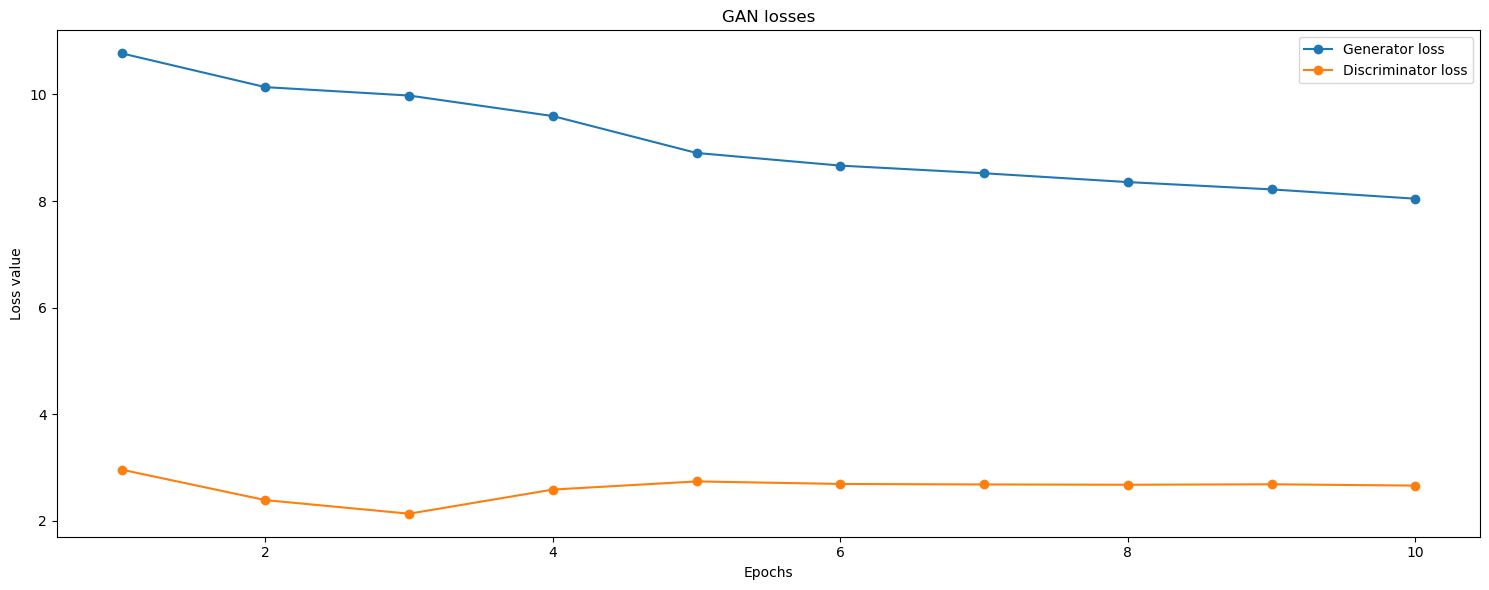

In [14]:
temporal_loss_array = np.array([losses_g, losses_d])
np.save('./temporal_GAN_losses_model2.npy',temporal_loss_array)

figure = plt.figure(figsize=(15,6))

titles = ['Generator loss', 'Discriminator loss']

plt.plot(range(1,(temporal_loss_array.shape[1]+1)), temporal_loss_array[0], label=titles[0], marker='o')
plt.plot(range(1,(temporal_loss_array.shape[1]+1)), temporal_loss_array[1], label=titles[1], marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss value')
plt.title('GAN losses')
plt.legend()

plt.tight_layout()
plt.show()


In [21]:
model_data = {
    "id": 2,              # Integer value 
    "start_epoch": 1,    # Integer
    "end_epoch": 10,     # Integer
    "depth": 8,           # No of layers,
    "interval": 1,       # Model save frequency in epochs
    "best_model": 10,     # Based on loss curves along with FID and KID scores 
    "date": "2025-09-16", # Format: YYYY-MM-DD # Best model date
}

selected_model_path = "../GAN models/Spatial models/NIR - based/Temporal/acgan_checkpoint-Model "+ str(model_data["id"]) +"-Epoch "+str(model_data["best_model"])+"_"+model_data["date"]+".pth"


In [ ]:
def ensure_clean_dir(path: str):
    if os.path.exists(path): shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)

@torch.no_grad()
def generate_fake_sequences_batch(G_wrapper, label_masks, T_ref, eval_doy_list, num_classes=10):
    """
    label_masks: torch.LongTensor (B,H,W) class ids
    Returns: torch.Tensor (B,T_ref,4,64,64) in [0,1] on CPU
    """
    one_hot = F.one_hot(label_masks, num_classes=num_classes).permute(0,3,1,2).float().to(label_masks.device)
    fake_seq = G_wrapper(one_hot, T_ref, eval_doy_list)  # (B,T,4,64,64), assume float
    fake_seq = fake_seq.detach()
    return fake_seq

# ---------- save matched REAL/FAKE PNGs for a single timestamp ----------
def save_matched_real_fake_for_doy(loader, fake_seq_all, t_idx_eval, out_real, out_fake):
    """
    For timestamp index t_idx_eval:
      - Save REAL frames imgs[:, t_idx_eval] from loader
      - Save FAKE frames fake_seq_all[:, t_idx_eval]
    Returns: number of pairs saved (min of the two counts)
    """
    ensure_clean_dir(out_real)
    ensure_clean_dir(out_fake)

    # --- REAL ---
    saved_real = 0
    for batch in loader:
        imgs = batch[0]                    # expect (B,T,4,64,64)
        imgs_t = imgs[:, t_idx_eval, ...].float()  # (B,4,64,64)
        imgs_t = (imgs_t.clamp(-1, 1) + 1) / 2
        for i in range(imgs_t.size(0)):
            save_image(imgs_t[i], os.path.join(out_real, f"{saved_real:06d}.png"))
            saved_real += 1

    # --- FAKE ---
    fake_t = fake_seq_all[:, t_idx_eval, ...]       # torch (N,4,64,64) in [0,1]
    saved_fake = 0
    for i in range(fake_t.size(0)):
        save_image(fake_t[i], os.path.join(out_fake, f"{saved_fake:06d}.png"))
        saved_fake += 1

    # If counts differ, trim the larger dir to the smaller count (keeps FID sane)
    n_pairs = min(saved_real, saved_fake)
    if saved_real != n_pairs:
        for k in range(n_pairs, saved_real):
            p = os.path.join(out_real, f"{k:06d}.png")
            if os.path.exists(p): os.remove(p)
    if saved_fake != n_pairs:
        for k in range(n_pairs, saved_fake):
            p = os.path.join(out_fake, f"{k:06d}.png")
            if os.path.exists(p): os.remove(p)

    return n_pairs

date_list = ['2025-09-12', '2025-09-12', '2025-09-13', '2025-09-13', '2025-09-14', '2025-09-14', '2025-09-15', '2025-09-15', '2025-09-16', '2025-09-16']

# Expect validation_data to be (N,T,4,64,64).
# If it's (N,T,64,64,4), transpose once:
if validation_data.ndim == 5 and validation_data.shape[2] != 4:
    if validation_data.shape[-1] == 4:
        validation_data = np.transpose(validation_data, (0, 1, 4, 2, 3)).copy()
    else:
        raise ValueError("validation_data has unexpected shape; expected (N,T,4,H,W).")

N, T_ref = validation_data.shape[0], validation_data.shape[1]

# Your dataset must yield (imgs, labels) where imgs is (B,T,4,64,64) tensor
dataset = ImageLabelDataset(validation_data, validation_labels)
loader = DataLoader(dataset, batch_size=16, shuffle=False)  # shuffle=False for reproducible counts

fid_list, kid_mean_list, kid_std_list = [], [], []

for epoch in range(model_data["end_epoch"], model_data["end_epoch"] + 1, model_data["interval"]):
    # ---- checkpoint path: fix quoting + avoid date_list indexing issues ----
    path = f"../GAN models/Spatial models/NIR - based/Temporal/acgan_checkpoint-Model {str(model_data['id'])}-Epoch {epoch}_{date_list[epoch-1]}.pth"

    # ---- rebuild models & load ----
    generator_temporal  = TemporalNoiseGenerator().to(DEVICE)
    discriminator_temporal = TemporalDiscriminator(feat_dim=384, hidden=256, layers=1, bidir=True).to(DEVICE)
    generator_spatial   = UNetTransformerGenerator(depth=8).to(DEVICE)
    discriminator_spatial = DiscriminatorWithLabelEmbedding().to(DEVICE)

    g_params      = list(generator_spatial.parameters()) + list(generator_temporal.parameters())
    g_optimizer   = torch.optim.Adam(g_params, lr=2e-5, betas=(0.5, 0.999))
    d_optimizer   = torch.optim.Adam(discriminator_spatial.parameters(), lr=2e-5, betas=(0.5, 0.999))
    d_optimizer_t = torch.optim.Adam(discriminator_temporal.parameters(), lr=2e-5, betas=(0.5, 0.999))

    _ = load_models(generator_spatial,
                    generator_temporal,
                    discriminator_spatial,
                    discriminator_temporal,
                    g_optimizer,
                    d_optimizer,
                    d_optimizer_t,
                    path)

    G = SequentialGeneratorWrapper(generator_spatial, generator_temporal).to(DEVICE)
    G.eval()

    # ---- generate FAKE sequences for all validation samples (batched) ----
    fake_chunks = []
    for imgs, labels in loader:
        labels = labels.long().to(DEVICE)                  # (B,H,W) label ids
        # Use your training DOY list (length T_ref)
        fake_seq_batch = generate_fake_sequences_batch(G, labels, T_ref, doy_list, num_classes=10)  # torch CPU
        fake_chunks.append(fake_seq_batch)
    fake_seq_all = torch.cat(fake_chunks, dim=0)           # (N,T,4,64,64) torch CPU in [0,1]

    # ---- per-timestamp metrics -> weighted aggregate ----
    per_t_fid, per_t_kid, per_t_kid_std, per_t_counts = [], [], [], []
    for t_idx in range(T_ref):
        real_dir = "./fid_real"
        fake_dir = "./fid_fake"

        n_pairs = save_matched_real_fake_for_doy(loader, fake_seq_all, t_idx, real_dir, fake_dir)
        if n_pairs < 5:
            # too small to be stable; skip this t
            ensure_clean_dir(real_dir)
            ensure_clean_dir(fake_dir)
            continue

        metrics = calculate_metrics(
            input1=real_dir,
            input2=fake_dir,
            fid=True,
            kid=True,
            verbose=False,
            cuda=False
        )

        per_t_fid.append(metrics['frechet_inception_distance'])
        per_t_kid.append(metrics['kernel_inception_distance_mean'])
        per_t_kid_std.append(metrics['kernel_inception_distance_std'])
        per_t_counts.append(n_pairs)

        print(f"[Epoch: {epoch} | t={t_idx}] FID={per_t_fid[-1]:.3f}  KID={per_t_kid[-1]:.6f}  (n={n_pairs})")

    if len(per_t_counts) == 0:
        print(f"[Epoch {epoch}] No valid timestamp pairs.")
        fid_list.append(np.nan); kid_mean_list.append(np.nan); kid_std_list.append(np.nan)
        continue

    w = np.asarray(per_t_counts, dtype=np.float64)
    w /= w.sum()

    fid_w     = float(np.sum(w * np.asarray(per_t_fid)))
    kid_w     = float(np.sum(w * np.asarray(per_t_kid)))
    kid_std_w = float(np.sum(w * np.asarray(per_t_kid_std)))  # rough combine

    fid_list.append(fid_w); kid_mean_list.append(kid_w); kid_std_list.append(kid_std_w)
    print(f"[Epoch {epoch}]  FID(weighted)={fid_w:.3f}  KID(weighted)={kid_w:.6f}")
